# Agent Specific Trip Analysis
Load policy case

In [183]:
# Analysis of Person Money Events

%config InlineBackend.figure_format = 'retina'

import pandas as pd
import geopandas as gpd

trips_file = "berlin-v6.4.output_trips.csv.zst"
persons_file = "berlin-v6.4.output_persons.csv.zst"

pct=0.1

base_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-baseCaseCtdExtended-10pct"
policy_base_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-policy-10pct_walkPlanFix"
policy_deparking_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-policy-10pct-deparking-p1_d0_i0_max1000_walkPlanFix"

base_trips = pd.read_csv("%s/%s" % (base_path, trips_file), sep=";", low_memory=False)
base_persons = pd.read_csv("%s/%s" % (base_path, persons_file), sep=";", low_memory=False)
policy_base_trips = pd.read_csv("%s/%s" % (policy_base_path, trips_file), sep=";", low_memory=False)
policy_deparking_trips = pd.read_csv("%s/%s" % (policy_deparking_path, trips_file), sep=";", low_memory=False)

In [2]:
base_trips.columns

Index(['person', 'trip_number', 'trip_id', 'dep_time', 'trav_time',
       'wait_time', 'traveled_distance', 'euclidean_distance', 'main_mode',
       'longest_distance_mode', 'modes', 'start_activity_type',
       'end_activity_type', 'start_facility_id', 'start_link', 'start_x',
       'start_y', 'end_facility_id', 'end_link', 'end_x', 'end_y',
       'first_pt_boarding_stop', 'last_pt_egress_stop'],
      dtype='str')

In [87]:
# Inner merge on trip_id:
# - keeps only rows where trip_id exists in BOTH dataframes
# - retains all columns from both dfs
# - adds suffixes for overlapping column names

base_x_policy_base_trips = base_trips.merge(
    policy_base_trips,
    on="trip_id",
    how="inner",
    suffixes=("_base", "_policy")
)

base_x_policy_deparking_trips = base_trips.merge(
    policy_deparking_trips,
    on="trip_id",
    how="inner",
    suffixes=("_base", "_policy")
)


In [88]:
print(base_x_policy_base_trips.columns)

Index(['person_base', 'trip_number_base', 'trip_id', 'dep_time_base',
       'trav_time_base', 'wait_time_base', 'traveled_distance_base',
       'euclidean_distance_base', 'main_mode_base',
       'longest_distance_mode_base', 'modes_base', 'start_activity_type_base',
       'end_activity_type_base', 'start_facility_id_base', 'start_link_base',
       'start_x_base', 'start_y_base', 'end_facility_id_base', 'end_link_base',
       'end_x_base', 'end_y_base', 'first_pt_boarding_stop_base',
       'last_pt_egress_stop_base', 'person_policy', 'trip_number_policy',
       'dep_time_policy', 'trav_time_policy', 'wait_time_policy',
       'traveled_distance_policy', 'euclidean_distance_policy',
       'main_mode_policy', 'longest_distance_mode_policy', 'modes_policy',
       'start_activity_type_policy', 'end_activity_type_policy',
       'start_facility_id_policy', 'start_link_policy', 'start_x_policy',
       'start_y_policy', 'end_facility_id_policy', 'end_link_policy',
       'end_x_poli

In [89]:
def to_seconds(series):
    timedeltas = pd.to_timedelta(series, errors="coerce")
    numeric = pd.to_numeric(series, errors="coerce")
    return timedeltas.dt.total_seconds().fillna(numeric)

bezirke = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/bezirksgrenzen.geojson").to_crs(epsg=3857)
umweltzone = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/umweltzone/Umweltzone_Berlin.shp").to_crs(epsg=3857)
bezirke_outline = bezirke.union_all()

In [90]:
base_x_policy_base_trips["trav_time_base"] = to_seconds(base_x_policy_base_trips["trav_time_base"])
base_x_policy_base_trips["trav_time_policy"] = to_seconds(base_x_policy_base_trips["trav_time_policy"])

base_x_policy_deparking_trips["trav_time_base"] = to_seconds(base_x_policy_deparking_trips["trav_time_base"])
base_x_policy_deparking_trips["trav_time_policy"] = to_seconds(base_x_policy_deparking_trips["trav_time_policy"])

base_x_policy_base_trips["travel_time_diff"] = base_x_policy_base_trips["trav_time_policy"] - base_x_policy_base_trips["trav_time_base"]
base_x_policy_deparking_trips["travel_time_diff"] = base_x_policy_deparking_trips["trav_time_policy"] - base_x_policy_deparking_trips["trav_time_base"]

<Axes: ylabel='Frequency'>

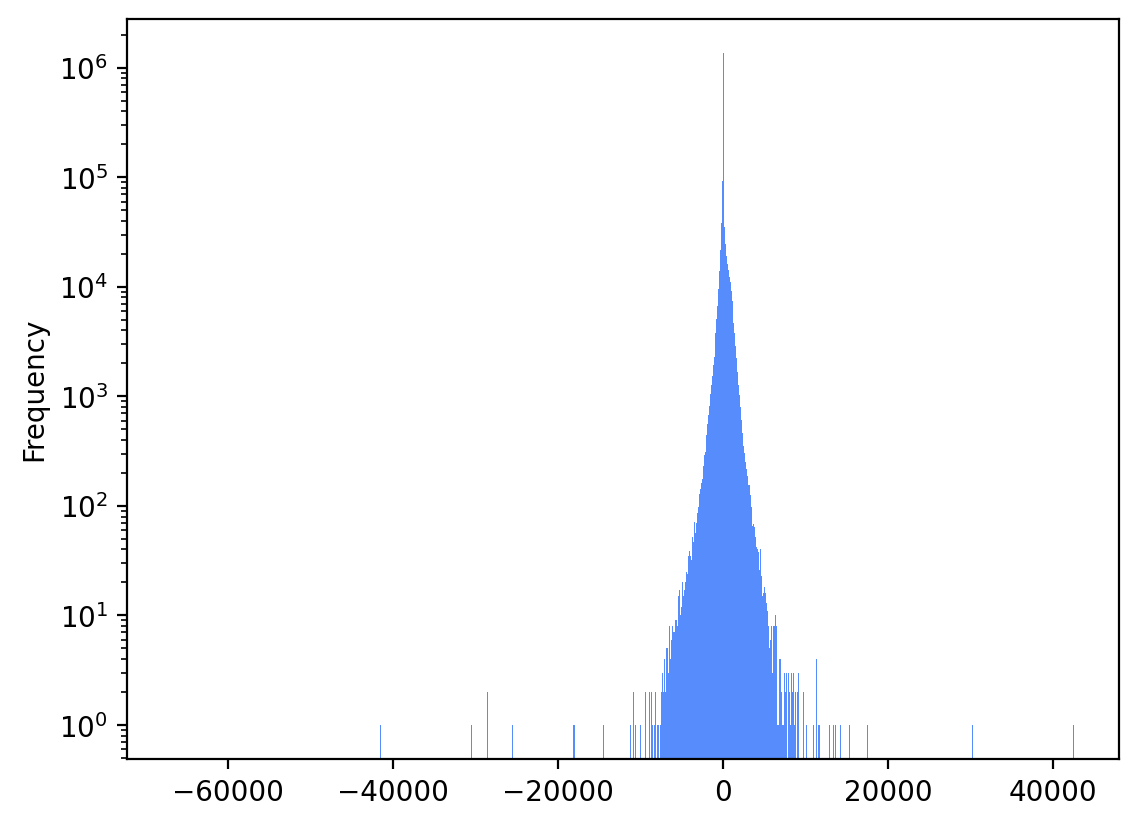

In [91]:
base_x_policy_base_trips["travel_time_diff"].plot.hist(bins=1000, log=True)

In [92]:
# print statistics of travel_time_diff
def print_travel_time_diff_stats(df, label):
    print(f"Statistics for {label}:")
    print(df["travel_time_diff"].describe())
    print(f"Share of trips with travel time increase: {(df['travel_time_diff'] > 0).mean():.2%}")
    print(f"Share of trips with travel time decrease: {(df['travel_time_diff'] < 0).mean():.2%}")
    print(f"Share of trips with travel time change > 5 min: {(df['travel_time_diff'] > 5*60).mean():.2%}")
    print(f"Share of trips with travel time change > 10 min: {(df['travel_time_diff'] > 10*60).mean():.2%}")
    print(f"Share of trips with travel time change > 15 min: {(df['travel_time_diff'] > 15*60).mean():.2%}")

print_travel_time_diff_stats(base_x_policy_base_trips, "Base vs Policy")
print("\n==== \n")
(print_travel_time_diff_stats(base_x_policy_deparking_trips, "Base vs Policy with deparking"))

Statistics for Base vs Policy:
count    1.819824e+06
mean     3.649044e+01
std      3.586860e+02
min     -6.671900e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.258300e+04
Name: travel_time_diff, dtype: float64
Share of trips with travel time increase: 21.72%
Share of trips with travel time decrease: 18.00%
Share of trips with travel time change > 5 min: 7.61%
Share of trips with travel time change > 10 min: 4.65%
Share of trips with travel time change > 15 min: 2.70%

==== 

Statistics for Base vs Policy with deparking:
count    1.819831e+06
mean     2.804184e+01
std      3.783300e+02
min     -2.542000e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.258300e+04
Name: travel_time_diff, dtype: float64
Share of trips with travel time increase: 21.07%
Share of trips with travel time decrease: 18.82%
Share of trips with travel time change > 5 min: 7.39%
Share of trips with travel time change > 10 min: 4.60%
Share of trips w

In [188]:
# make a matrix of main_mode_base and main_mode_policy. count how many trips fall into each combination of modes. also report the mean travel_time_diff for each combination of modes. create a function that takes a merged dataframe and returns the data frame
def mode_combination_matrix(df):
    mode_matrix = df.groupby(["main_mode_base", "main_mode_policy"]).agg(
        trip_count=("trip_id", "count"),
        mean_travel_time_diff=("travel_time_diff", "mean"),
        sum_travel_time_diff_hr=("travel_time_diff", "sum")
    ).reset_index()
    mode_matrix["trip_count"] /= pct
    mode_matrix["sum_travel_time_diff_hr"] /= 3600
    mode_matrix["sum_travel_time_diff_hr"] /= pct
    return mode_matrix

# create a function that takes the mode combination matrix and plots a heatmap of trip_count and mean_travel_time_diff
def plot_mode_combination_heatmap(mode_matrix, value_col, title, cmap="bwr", center=True):
    pivot_table = mode_matrix.pivot(index="main_mode_base", columns="main_mode_policy", values=value_col)
    # filter out rows where main_mode_base is commercial_goods_car, freight or truck
    exclude = ["commercial_goods_car", "freight", "truck"]
    pivot_table = pivot_table.loc[
        ~pivot_table.index.isin(exclude),
        ~pivot_table.columns.isin(exclude)
    ]
    plt.figure(figsize=(10, 8))
    if center:
        sns.heatmap(
            pivot_table,
            annot=True,
            fmt=",.0f",      # thousands separators, no decimals
            cmap=cmap,
            center=0
        )
    else:
        sns.heatmap(
            pivot_table,
            annot=True,
            fmt=",.0f",      # thousands separators, no decimals
            cmap=cmap
        )
    plt.title(title)
    plt.show()

In [189]:
mode_matrix_base_policy = mode_combination_matrix(base_x_policy_base_trips)
mode_matrix_base_deparking = mode_combination_matrix(base_x_policy_deparking_trips)

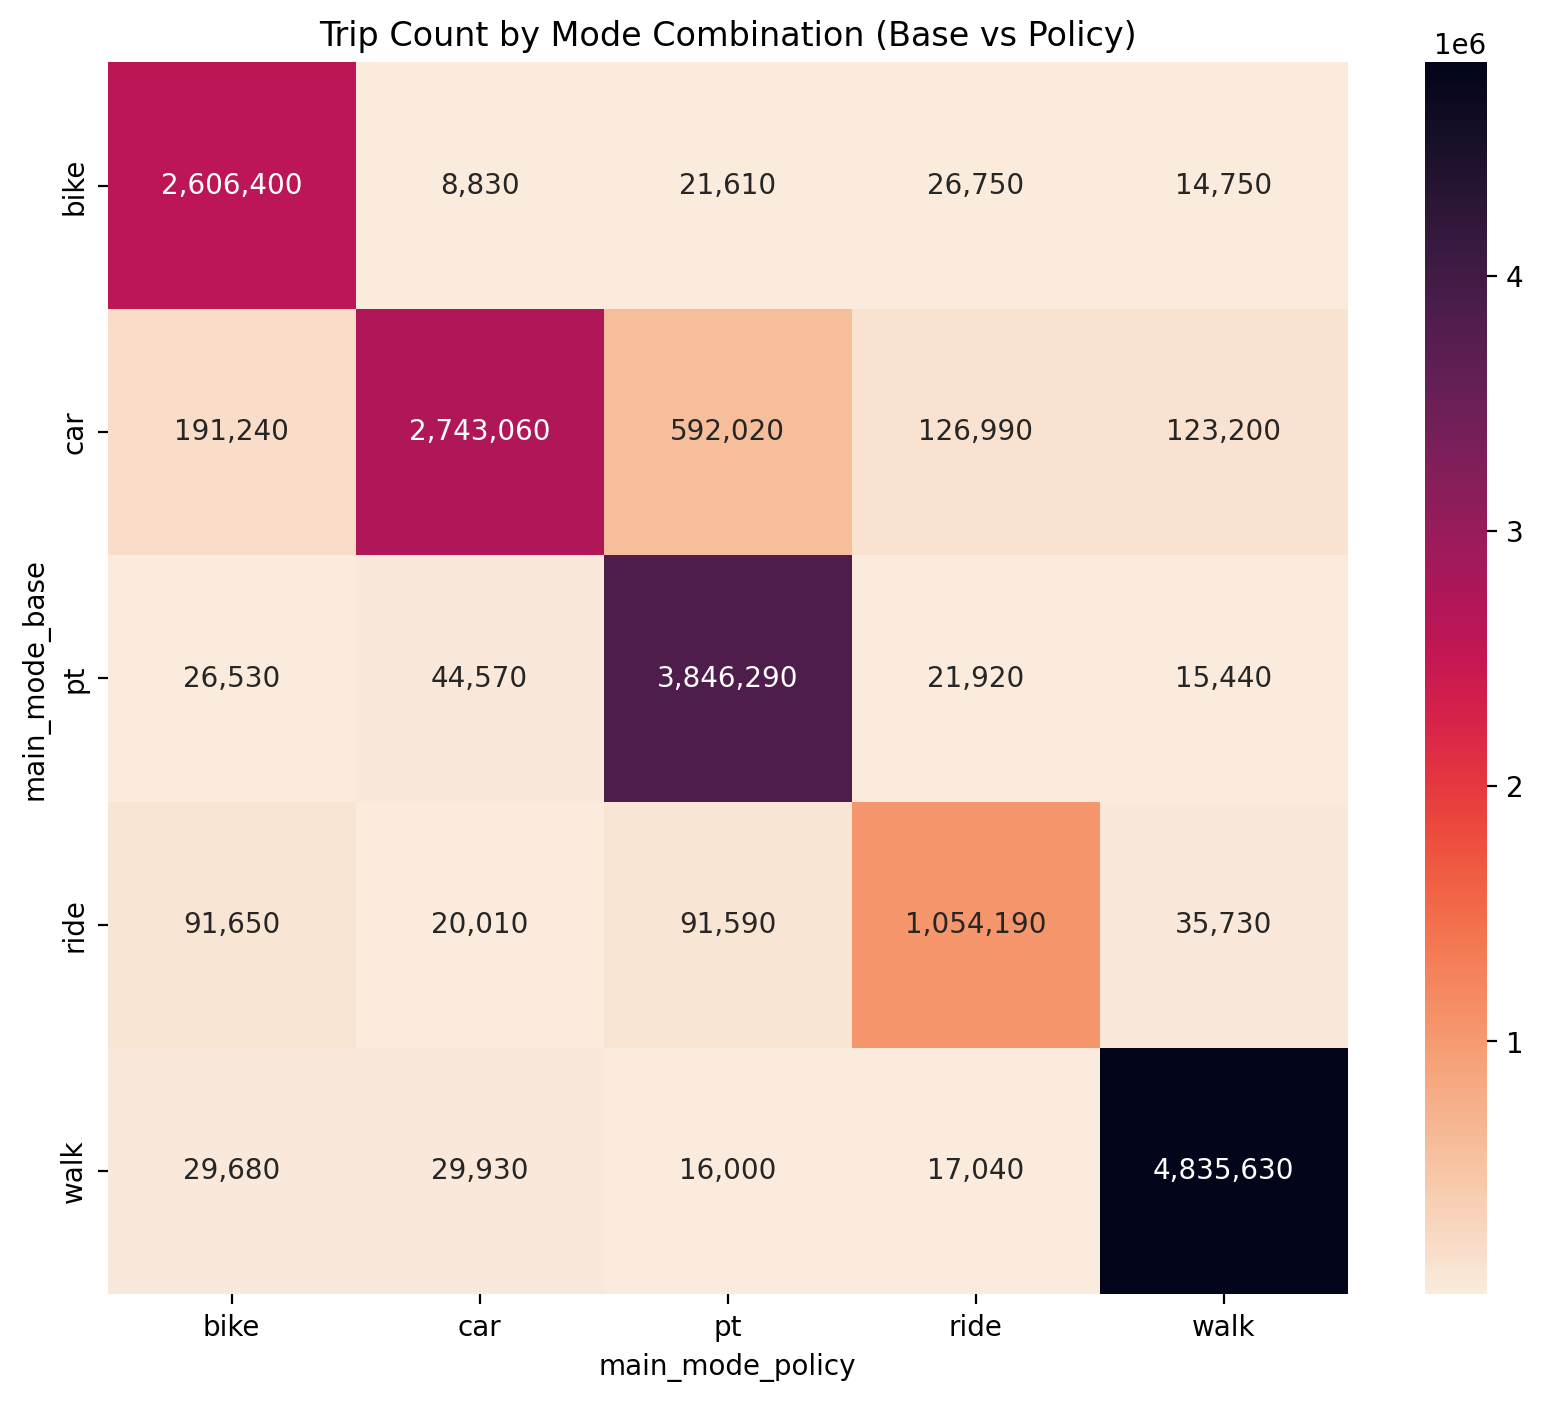

In [190]:
plot_mode_combination_heatmap(mode_matrix_base_deparking, "trip_count", "Trip Count by Mode Combination (Base vs Policy)", cmap="rocket_r", center=False)

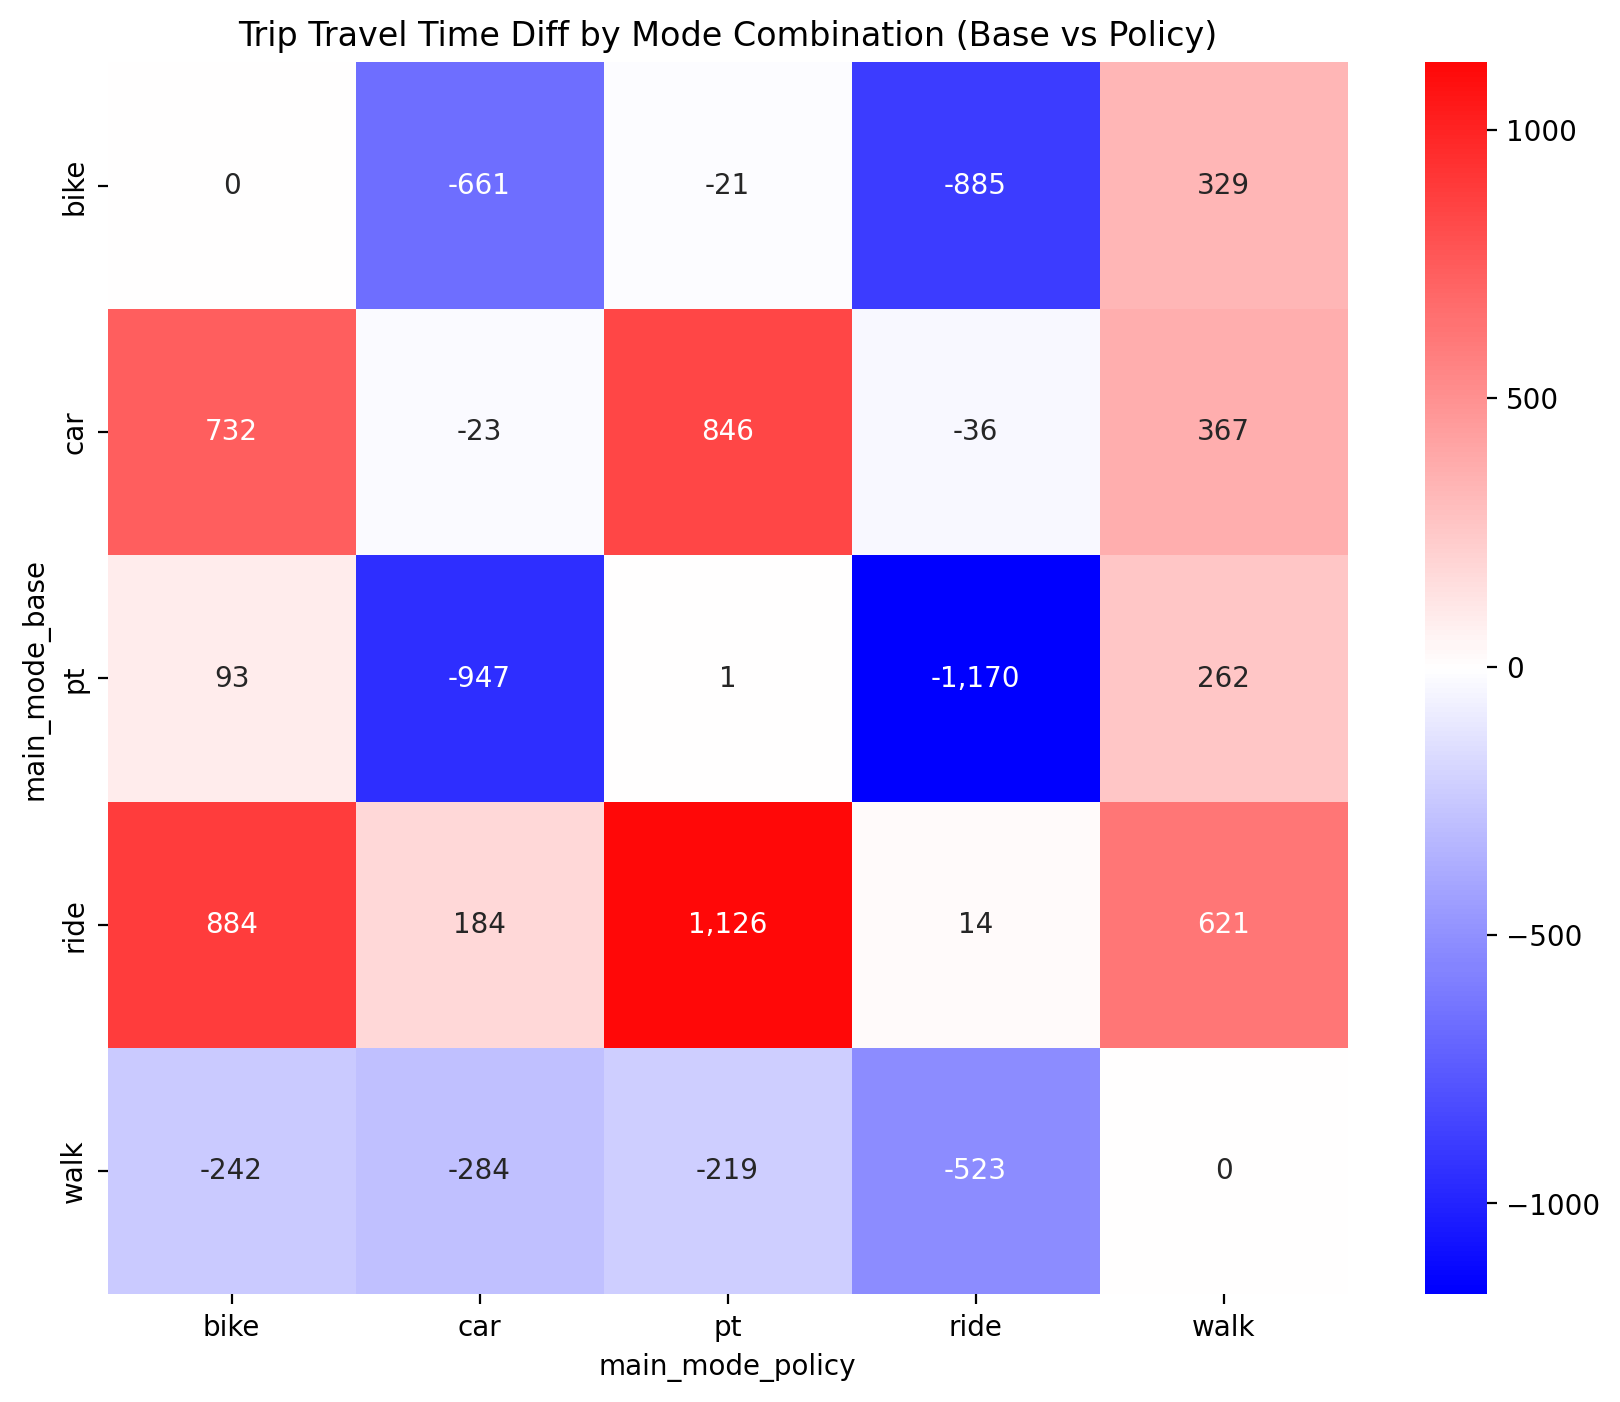

In [191]:
plot_mode_combination_heatmap(mode_matrix_base_deparking, "mean_travel_time_diff", "Trip Travel Time Diff by Mode Combination (Base vs Policy)")


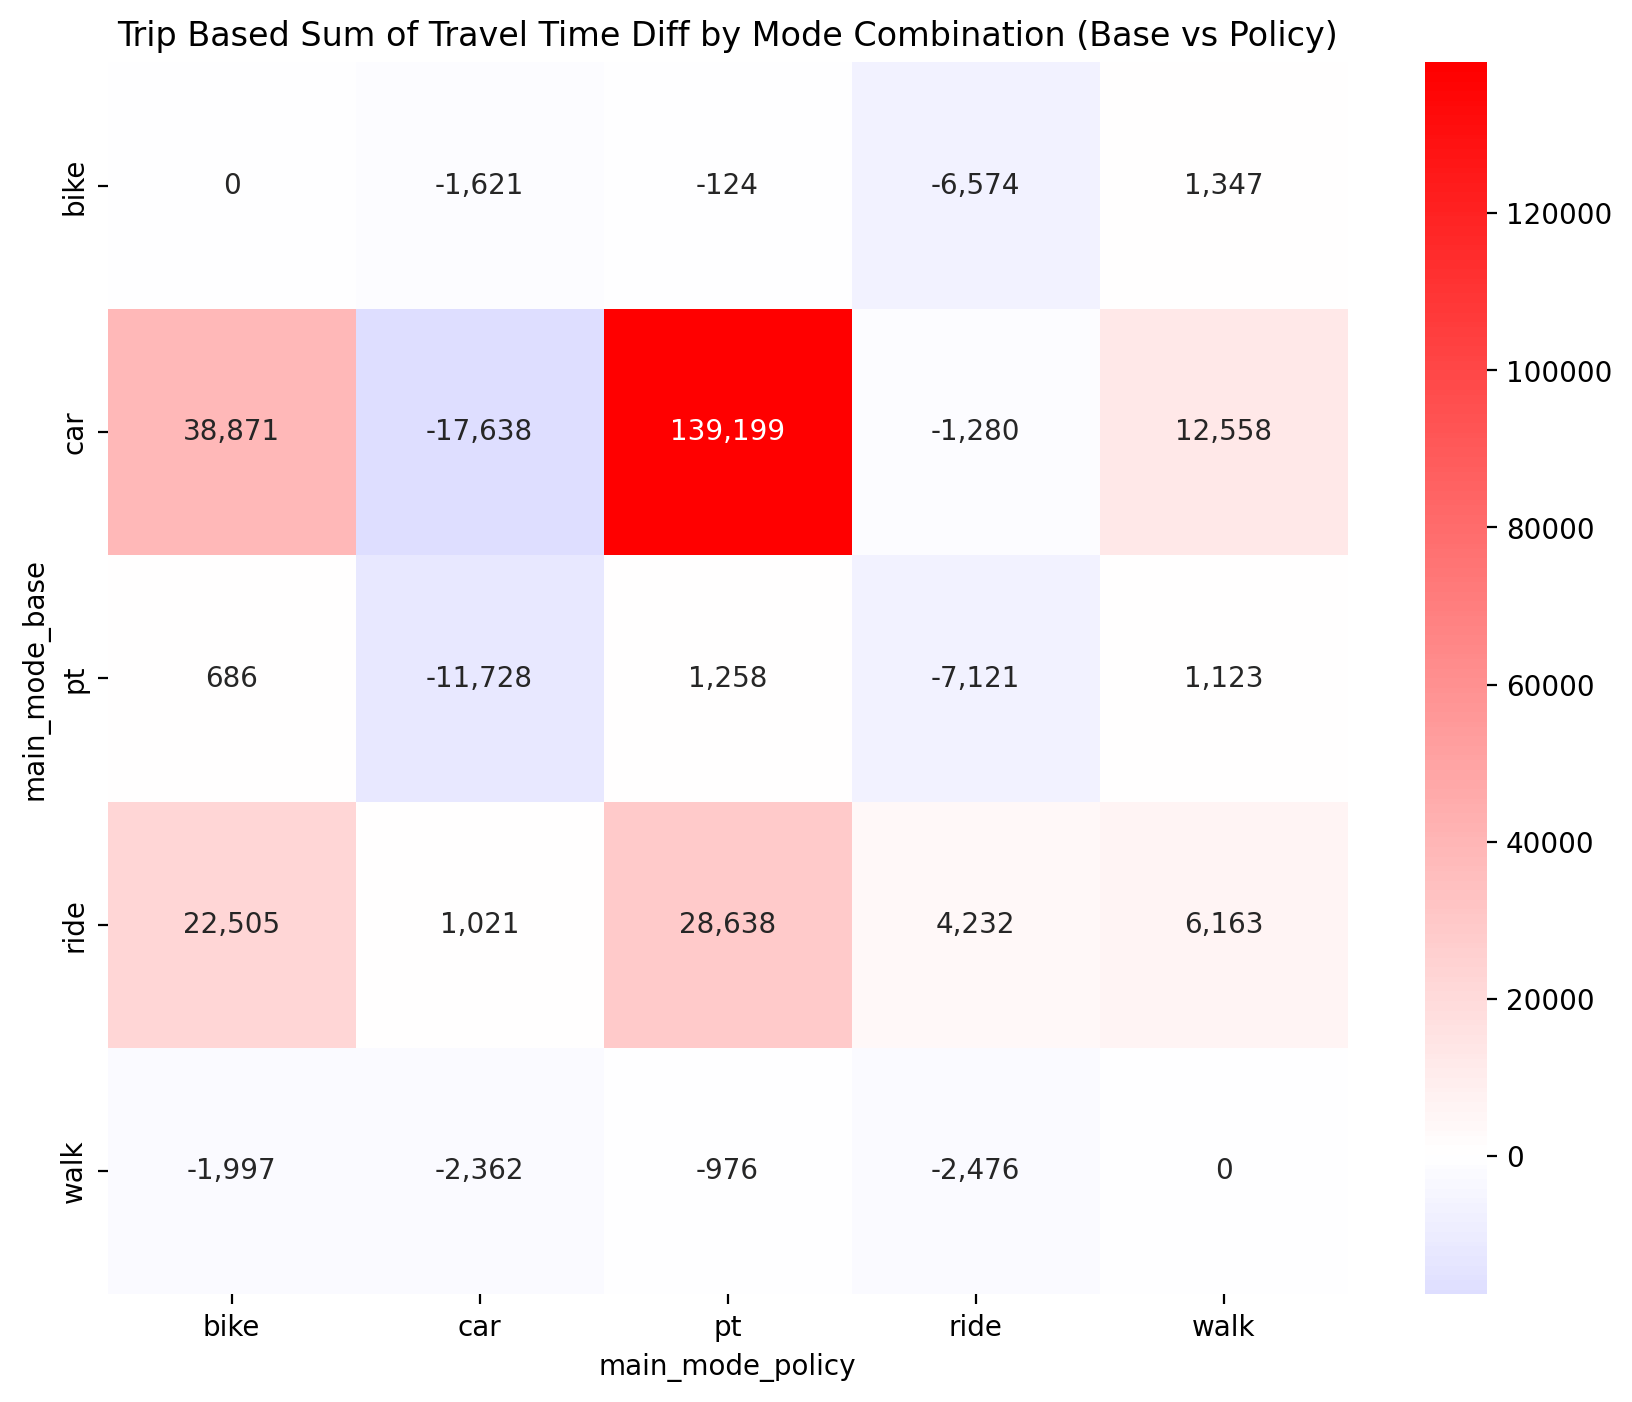

In [192]:
plot_mode_combination_heatmap(mode_matrix_base_deparking, "sum_travel_time_diff_hr", "Trip Based Sum of Travel Time Diff by Mode Combination (Base vs Policy)")


In [193]:
# make a facet heatmap plot. use bezirke and umweltzone to cluster trips.

# 1) merge base_persons with base_x_policy_base_trips and base_x_policy_deparking_trips on person_id, keep the home_x and home_y columns from base_persons, keep all columns from the trips dataframes, add suffixes to distinguish between the two merges
def merge_persons_trips(persons_df, trips_df):
    merged = trips_df.merge(
        persons_df[["person", "home_x", "home_y"]],
        left_on="person_base",
        right_on="person",
        how="left",
    )
    return merged

base_x_policy_base_trips_home = merge_persons_trips(base_persons, base_x_policy_base_trips)
base_x_policy_deparking_trips_home = merge_persons_trips(base_persons, base_x_policy_deparking_trips)

# 2) use the bezirke and umweltzone dfs to cluster the persons: if home in umweltzone, cluster "inner", if not in umwelt, but in bezirke, cluster as "outer", else "brandenburg"
def cluster_persons_by_location(df, bezirke_gdf, umweltzone_gdf):
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["home_x"], df["home_y"]),
        crs="EPSG:25832"
    )
    # check if points are in umweltzone
    gdf["cluster"] = "brandenburg"
    gdf.loc[gdf.geometry.within(bezirke_gdf.to_crs("EPSG:25832").union_all()), "cluster"] = "outer"
    gdf.loc[gdf.geometry.within(umweltzone_gdf.to_crs("EPSG:25832").union_all()), "cluster"] = "inner"
    return gdf

In [194]:
base_x_policy_base_trips_home = cluster_persons_by_location(base_x_policy_base_trips_home, bezirke, umweltzone)
base_x_policy_deparking_trips_home = cluster_persons_by_location(base_x_policy_deparking_trips_home, bezirke, umweltzone)

In [195]:
base_x_policy_base_trips_home["cluster"].describe()

count     1819824
unique          3
top         outer
freq       899122
Name: cluster, dtype: object

In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def mode_combination_matrix_cluster(df):
    mode_matrix = (
        df.groupby(
            ["cluster", "main_mode_base", "main_mode_policy"],
            as_index=False
        )
        .agg(
            trip_count=("trip_id", "count"),
            mean_travel_time_diff=("travel_time_diff", "mean"),
            sum_travel_time_diff_hr=("travel_time_diff", "sum")
        )
    )
    mode_matrix["sum_travel_time_diff_hr"] /= 3600
    mode_matrix["sum_travel_time_diff_hr"] /= pct
    mode_matrix["trip_count"] /= pct
    return mode_matrix

def plot_mode_combination_heatmap_facet(
        mode_matrix,
        value_col,
        title,
        cmap="bwr",
        center=True
):
    exclude = ["commercial_goods_car", "freight", "truck"]

    clusters = sorted(mode_matrix["cluster"].dropna().unique())

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 5),
        sharey=True
    )

    vmin = mode_matrix[value_col].min()
    vmax = mode_matrix[value_col].max()

    for i, (ax, cluster) in enumerate(zip(axes, clusters)):
        subset = mode_matrix[mode_matrix["cluster"] == cluster]

        pivot_table = subset.pivot(
            index="main_mode_base",
            columns="main_mode_policy",
            values=value_col
        )

        pivot_table = pivot_table.loc[
            ~pivot_table.index.isin(exclude),
            ~pivot_table.columns.isin(exclude)
        ]

        labels = pivot_table.apply(
            lambda col: col.map(
                lambda x: f"{x:,.0f}" if pd.notna(x) else ""
            )
        )

        sns.heatmap(
            pivot_table,
            square=True,
            annot=labels,
            fmt="",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            center=0 if center else None,
            ax=ax,
            cbar=(i == len(clusters) - 1)  # only one colorbar
        )

        ax.set_title(f"Home: {cluster}")

        # hide repeated y-axis labels
        if i > 0:
            ax.set_ylabel("")
            ax.tick_params(axis="y", left=False, labelleft=False)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

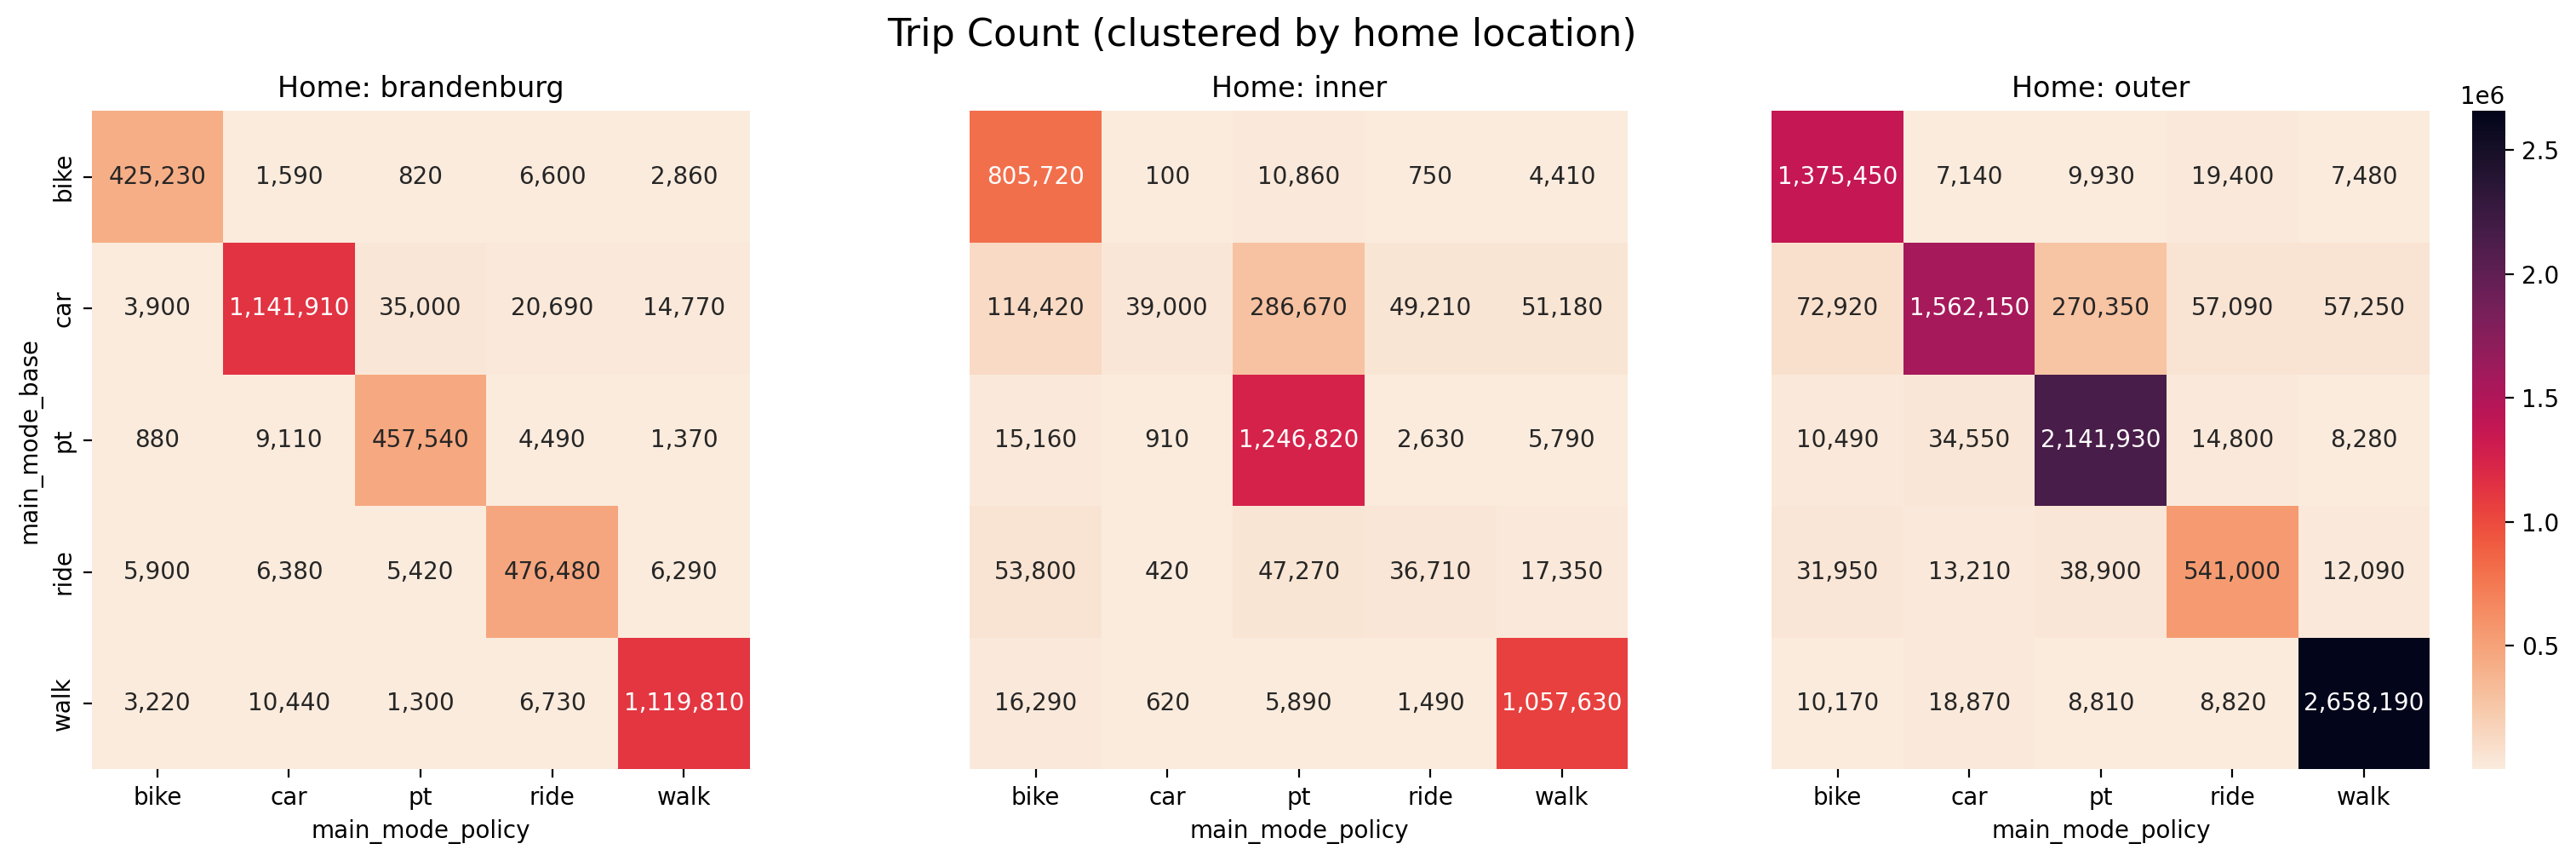

In [197]:
plot_mode_combination_heatmap_facet(mode_combination_matrix_cluster(base_x_policy_deparking_trips_home), "trip_count", "Trip Count (clustered by home location)", "rocket_r", center=False)

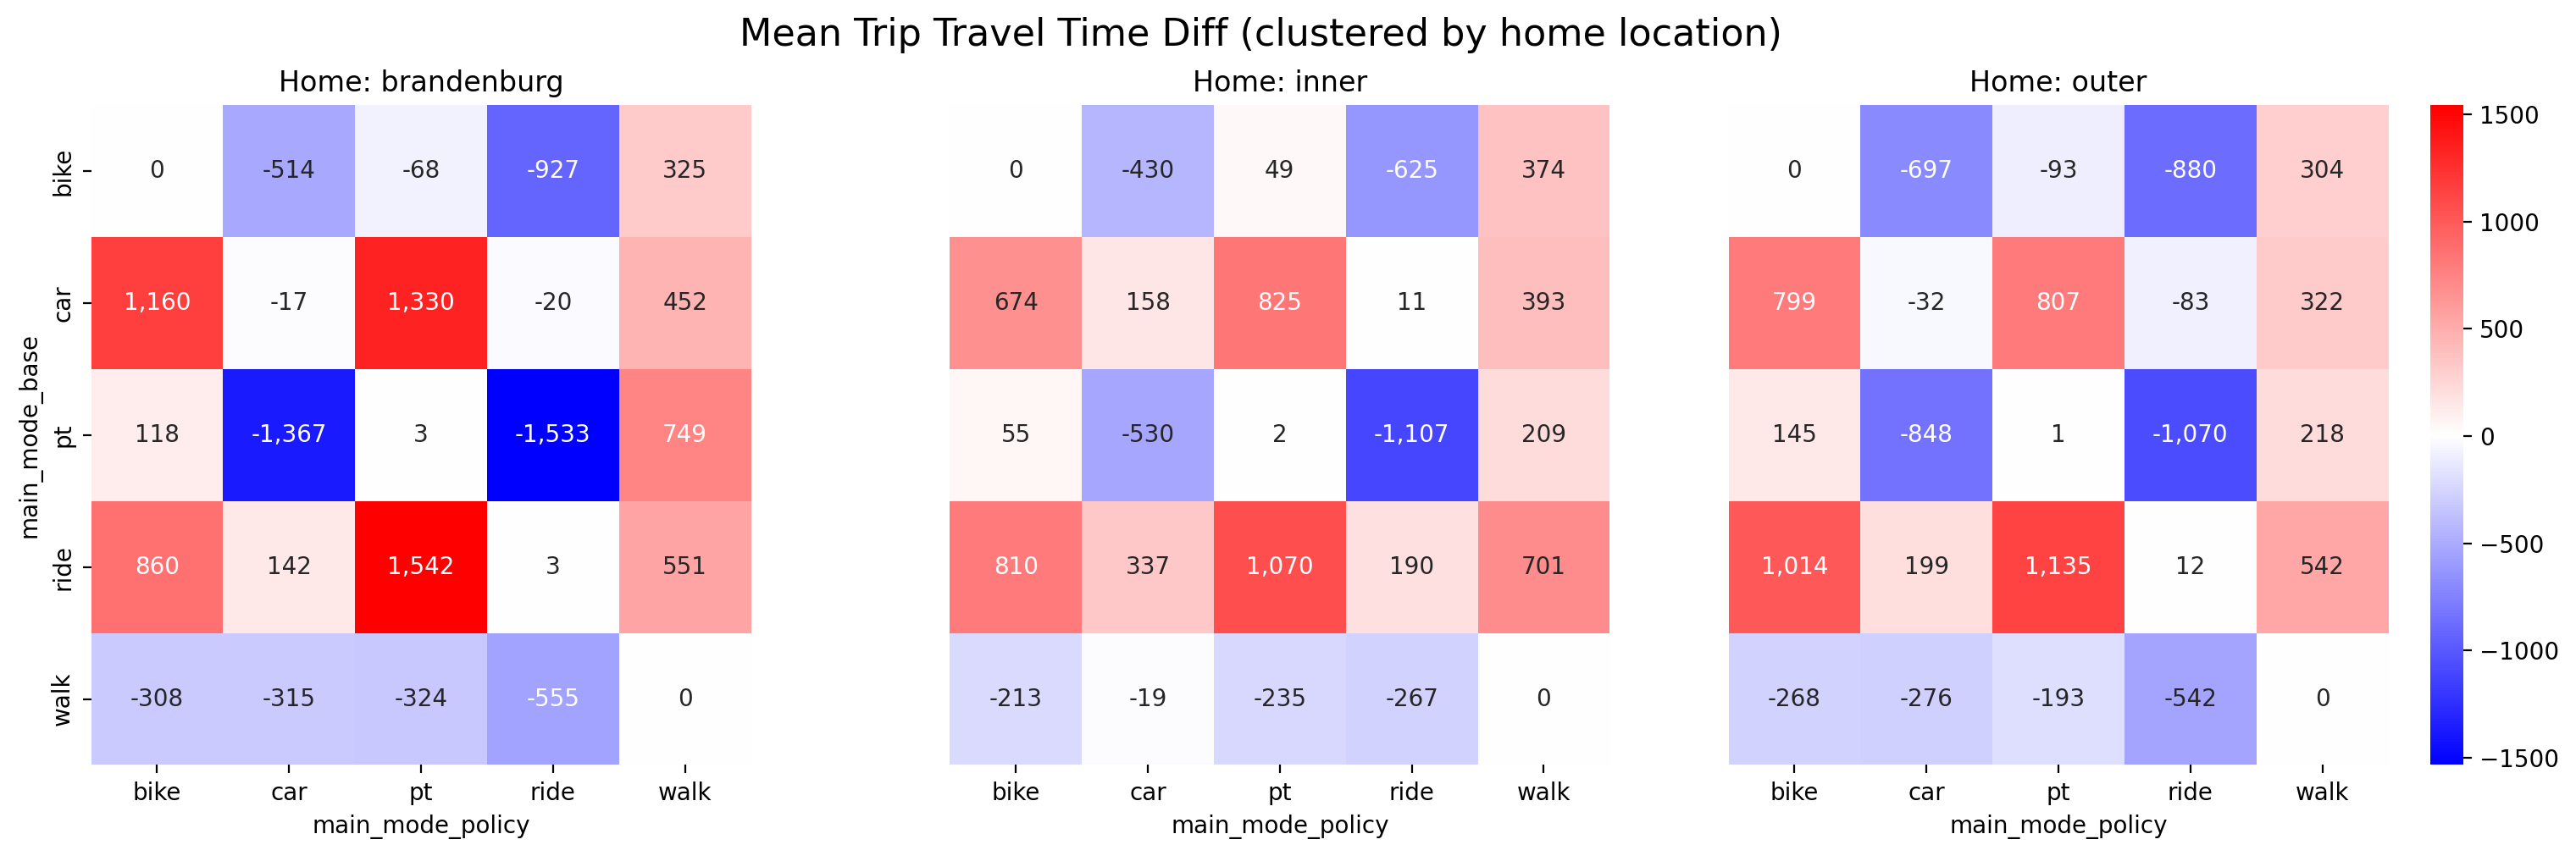

In [201]:
plot_mode_combination_heatmap_facet(mode_combination_matrix_cluster(base_x_policy_deparking_trips_home),
                                    "mean_travel_time_diff", "Mean Trip Travel Time Diff (clustered by home location)")

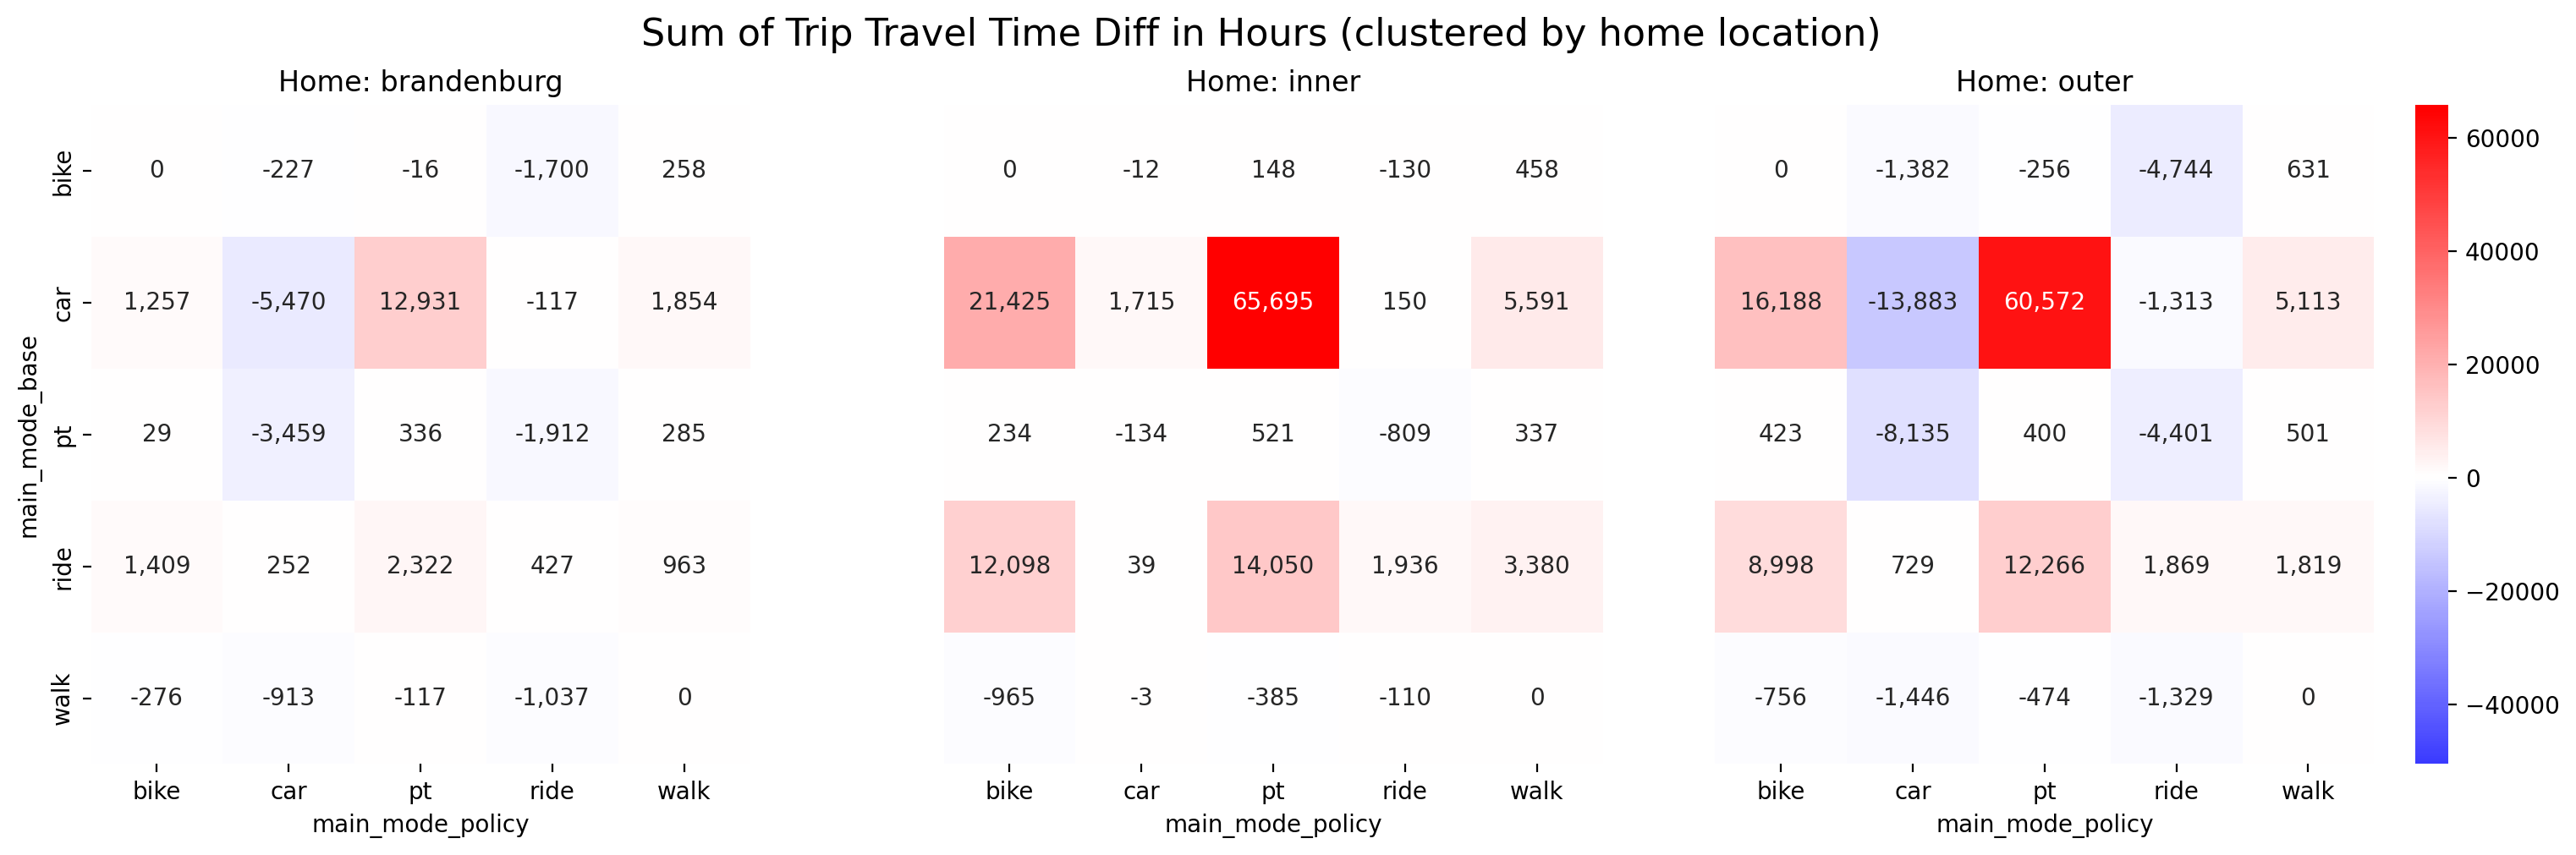

In [202]:
plot_mode_combination_heatmap_facet(mode_combination_matrix_cluster(base_x_policy_deparking_trips_home),
                                    "sum_travel_time_diff_hr", "Sum of Trip Travel Time Diff in Hours (clustered by home location)")